<a href="https://colab.research.google.com/github/Matteo-Raschi/Open_Data_Workshop_GW_2026/blob/main/Challenge3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -q lalsuite gwpy pycbc
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 71.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


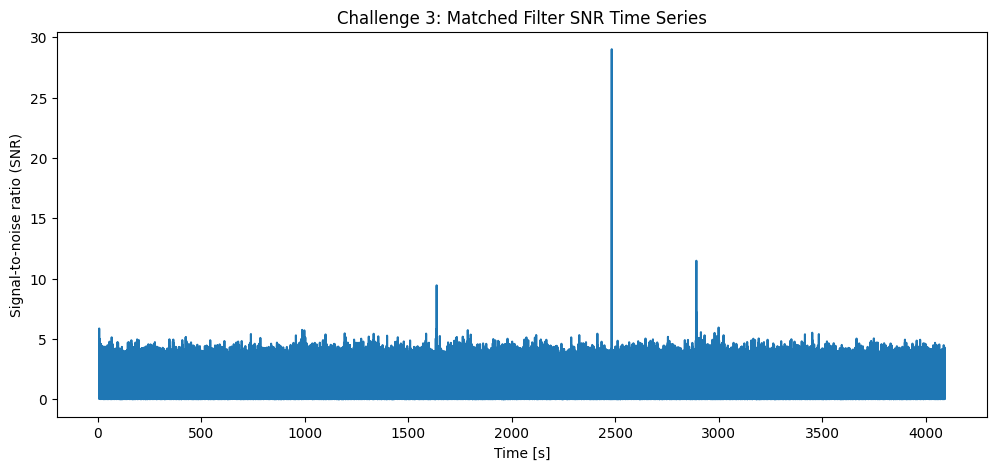

FINAL SOLUTIONS FOR CHALLENGE 3
A. The precise merger time of the loud signal (GPS): 2483.97
B. The matched-filter SNR of the loud signal:        29.01


In [2]:
import pycbc.frame
from pycbc.filter import matched_filter
from pycbc.waveform import get_td_waveform
from pycbc.psd import interpolate, inverse_spectrum_truncation
import matplotlib.pyplot as plt
import numpy as np

data_file = 'challenge3.gwf'
channel = 'H1:CHALLENGE3'


# 1. Load the data


pycbc_strain = pycbc.frame.read_frame(data_file, channel)
sample_rate = int(pycbc_strain.sample_rate)

# 2. Generate the template waveform

hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=10,
                         mass2=10,
                         spin1z=0,
                         spin2z=0,
                         delta_t=pycbc_strain.delta_t,
                         f_lower=20)

# Resize and shift template for matched filtering

hp.resize(len(pycbc_strain))
template = hp.cyclic_time_shift(hp.start_time)


# 3. Calculate PSD
# Use 4 second segments

psd = pycbc_strain.psd(4)
psd = interpolate(psd, pycbc_strain.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * pycbc_strain.sample_rate), low_frequency_cutoff=20)


# 4. Calculate Matched Filter SNR

snr = matched_filter(template, pycbc_strain, psd=psd, low_frequency_cutoff=20)

# Remove the beginning and end of the SNR time series to avoid filtering artifacts

snr = snr.crop(4 + 4, 4)

# Plot the SNR
plt.figure(figsize=(12, 5))
plt.plot(snr.sample_times, abs(snr))
plt.title("Challenge 3: Matched Filter SNR Time Series")
plt.ylabel("Signal-to-noise ratio (SNR)")
plt.xlabel("Time [s]")
plt.show()


# 5. Find the loud signal peak
# We find the absolute maximum SNR value and its corresponding time

peak_idx = abs(snr).numpy().argmax()
peak_snr = snr[peak_idx]
precise_merger_time = snr.sample_times[peak_idx]


# SUMMARY / FINAL SOLUTIONS

print("=" * 60)
print("FINAL SOLUTIONS FOR CHALLENGE 3")
print("=" * 60)
print(f"A. The precise merger time of the loud signal (GPS): {precise_merger_time:.2f}")
print(f"B. The matched-filter SNR of the loud signal:        {abs(peak_snr):.2f}")
print("=" * 60)
